In [2]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/processed/ecommerce_encoded.csv")

In [4]:
df.head()


,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending
0,100001,5033,2,1360,2,0.000000,0,0,0,56,1,3,0,0
1,100002,5038,3,4272,2,64.000000,0,0,0,46,0,3,0,0
2,100003,5266,5,3592,2,0.000000,0,0,0,32,1,5,0,0
3,100004,5120,1,966,2,2.666667,0,0,0,25,1,6,0,0
4,100005,5191,1,4926,2,627.500000,2,0,0,38,1,3,0,0


In [5]:
cluster_data = df[
[
    "Browsing_Time",
    "Previous_Purchases",
    "Total_Spending",
    "Rating",
    "Price"
]
]

In [6]:
cluster_data.head()

,Browsing_Time,Previous_Purchases,Total_Spending,Rating,Price
0,0.000000,0,0,2,1360
1,64.000000,0,0,2,4272
2,0.000000,0,0,2,3592
3,2.666667,0,0,2,966
4,627.500000,2,0,2,4926


In [7]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

In [8]:
joblib.dump(
    scaler,
    "../models/clustering_scaler.pkl"
)

['../models/clustering_scaler.pkl']

In [9]:
inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    inertia.append(model.inertia_)

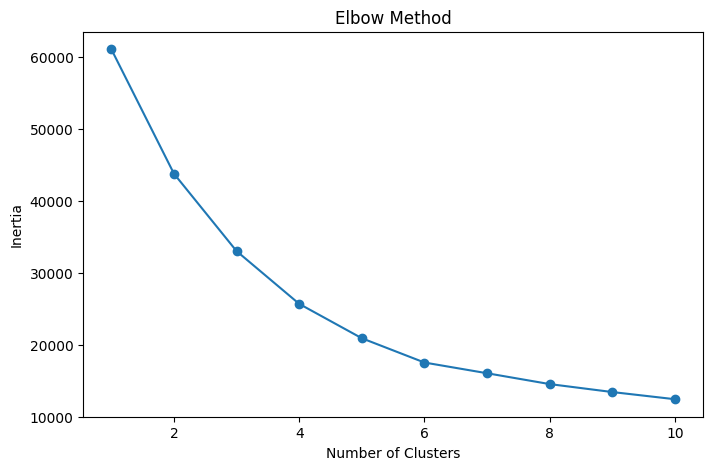

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(scaled_data)

,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [11]:
df["Cluster"] = kmeans.labels_

In [12]:
df.head()

,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending,Cluster
0,100001,5033,2,1360,2,0.000000,0,0,0,56,1,3,0,0,0
1,100002,5038,3,4272,2,64.000000,0,0,0,46,0,3,0,0,1
2,100003,5266,5,3592,2,0.000000,0,0,0,32,1,5,0,0,1
3,100004,5120,1,966,2,2.666667,0,0,0,25,1,6,0,0,0
4,100005,5191,1,4926,2,627.500000,2,0,0,38,1,3,0,0,1


In [13]:
df["Cluster"].value_counts()

Cluster
0    4931
1    4767
2    1824
3     683
Name: count, dtype: int64

In [14]:
score = silhouette_score(
    scaled_data,
    df["Cluster"]
)

print("Silhouette Score :", score)

Silhouette Score : 0.38032122868088625


In [15]:
cluster_summary = df.groupby("Cluster")[
[
"Browsing_Time",
"Previous_Purchases",
"Total_Spending",
"Rating",
"Price"
]
].mean()

cluster_summary

,Browsing_Time,Previous_Purchases,Total_Spending,Rating,Price
Cluster,,,,,
0,897.937226,4.116812,66.369702,2.087406,1610.221456
1,860.016898,3.916090,0.000000,2.067548,3865.783302
2,1531.113598,6.591557,2454.458333,4.299890,2977.205592
3,7075.518019,32.783309,654.975110,2.433382,2640.115666


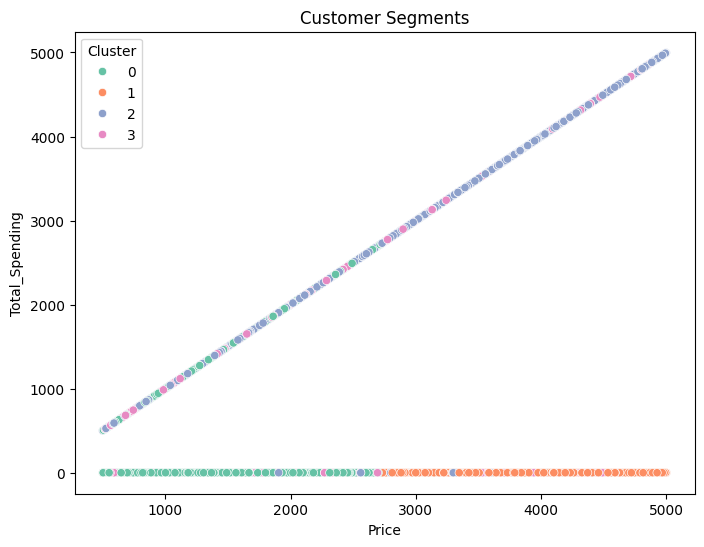

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(

x="Price",

y="Total_Spending",

hue="Cluster",

data=df,

palette="Set2"

)

plt.title("Customer Segments")

plt.show()

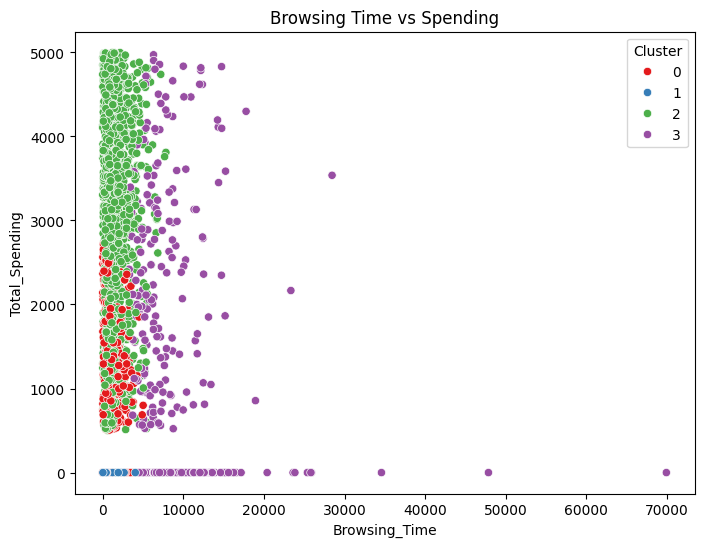

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(

x="Browsing_Time",

y="Total_Spending",

hue="Cluster",

data=df,

palette="Set1"

)

plt.title("Browsing Time vs Spending")

plt.show()

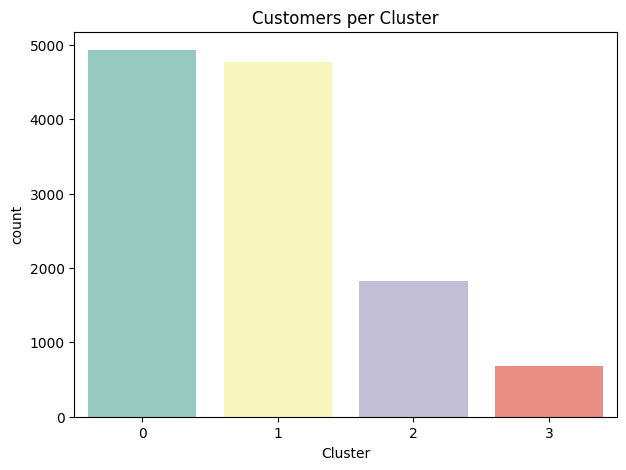

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(

x="Cluster",

data=df,

palette="Set3"

)

plt.title("Customers per Cluster")

plt.show()

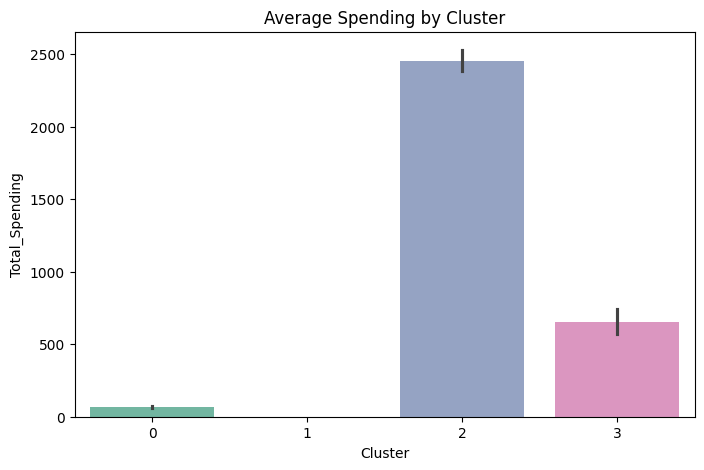

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(

x="Cluster",

y="Total_Spending",

data=df,

palette="Set2"

)

plt.title("Average Spending by Cluster")

plt.show()


In [21]:
cluster_names = {

0:"Frequent Buyers",

1:"Window Shoppers",

2:"Discount Lovers",

3:"Premium Customers"

}

df["Customer_Segment"] = df["Cluster"].map(cluster_names)

In [22]:
df["Customer_Segment"].value_counts()

Customer_Segment
Frequent Buyers      4931
Window Shoppers      4767
Discount Lovers      1824
Premium Customers     683
Name: count, dtype: int64

In [23]:
df.to_csv(

"../data/processed/ecommerce_clustered.csv",

index=False

)

In [24]:
joblib.dump(

kmeans,

"../models/kmeans_model.pkl"

)

['../models/kmeans_model.pkl']

In [25]:
loaded_model = joblib.load(

"../models/kmeans_model.pkl"

)

print("Model Loaded Successfully")


Model Loaded Successfully


In [26]:
sample = scaled_data[0].reshape(1,-1)

cluster = loaded_model.predict(sample)

print("Predicted Cluster :", cluster[0])



Predicted Cluster : 0


In [27]:
cluster_summary.to_csv(

"../reports/cluster_summary.csv"

)
